## Introduction & refresher
In this project we make reference to three lensing models:
- **Simple lensing.** 15 GW parameters, time delay, relative magnification.
- **Generic lensing.** 15 GW parameters, time delay, relative magnification, relative chirp mass, $\Delta\iota$, $\Delta\phi_c$, $\Delta\psi$.
- **AGN-CBC lensing.** 15 GW parameters, time delay, relative magnification, $M_{lz}$, $y\equiv\beta/R_{\mathrm{orb}}$, $R_{\mathrm{orb}}$.

We wish to solve for the SNR required to achieve enough evidence for second-order lensing effects. Evidence is quantified by the Bayes factor computed as the Savage–Dickey density ratio (SDDR). The two second-order lensing models go through different Fisher pipelines:
- **Generic lensing model.** The intrinsic AGN parameters ($M_{Lz}$, $y$, $R_{\mathrm{orb}}$) are converted to phenomenological changes and then injected into `GeneralLensedGWSignal`, from with the Fisher matrix is computed with `gwfast`
- **AGN-CBC lensing model.** The intrinsic AGN parameters are injected into `AGNLensedGWSignal`, from which the Fisher matrix is computed. The matrix is then transformed into one expressed in terms of phenomenological parameters, where the transfomation Jacobian is derived from the **lensing transform**, i.e., the transformation of intrinsic AGN parameters to phenomenological parameters.

We thus obtain a Fisher matrix w.r.t. only phenomenological parameters. The Fisher matrix w.r.t the simple model is also computed, and the two are used to calculate the SDDR (since the simple model is nested inside the phenomenological/generic model).

**We've previously obtained sensible plots with the generic model (below left), while the AGN model has consistently returned absurdly low SNR thresholds (below right). I argue here that that is the expected outcome given a (near) singular Jacobian, and the plots are not physically meaningful.**

Left: generic model  Right: AGN model


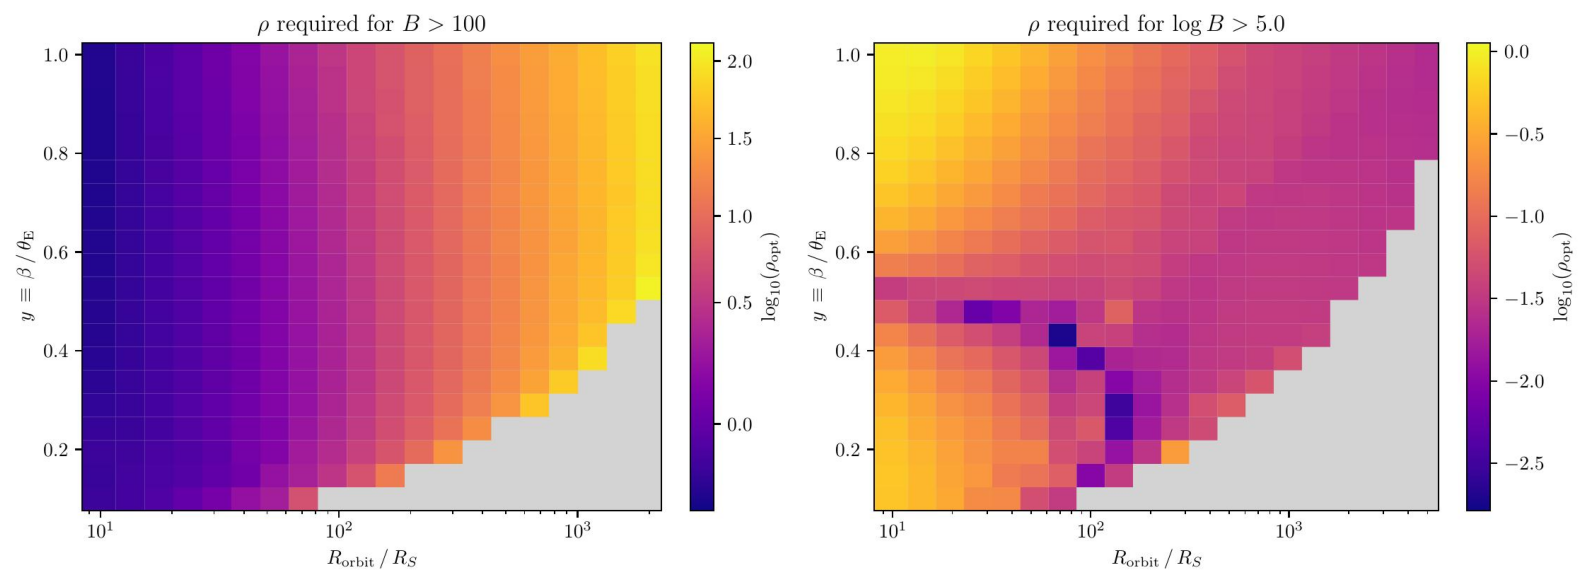

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

generic_img = mpimg.imread('snr_threshold_sddr_generic_B100-newcapped-newton15_Ry_plot-1.jpg')
agn_img = mpimg.imread('sddr_agn_logB5_20steps_O5_26658010_Ryplot-1.jpg')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(generic_img)
axes[0].axis('off')
axes[1].imshow(agn_img)
axes[1].axis('off')
plt.tight_layout()

print('Left: generic model  Right: AGN model')

The AGN (right) plot shows that the required SNR is universally $<10$ even when the threshold is set very high at $\log B=5$. Not only that, it has the wrong trend going from small $R_{\mathrm{orb}}$ to large $R_{\mathrm{orb}}$, and a weird belt of extremely low SNR in the lower left quadrant of the plot.

## My diagnosis
The nontrivial block of the Jacobian of the lensing (AGN $\rightarrow$ generic) transformation is $6\times5$:
$$(\iota,\, d_L,\, M_{lz},\, y,\, R_{\mathrm{orb}}) \rightarrow 
(\Delta t,\, \mathrm{rel.\,}d_L,\, \mathrm{rel.\,}\mathcal{M},\, \Delta\iota,\, \Delta\phi_c,\, \Delta\psi)$$
which is rank-deficient, meaning the transformed Fisher matrix is singular, and that's why our first method $B=\sqrt{\det F'/\det F}$ kept failing. We already knew this months ago.

The SDDR method evades this problem by looking at only the extra parameter block of the transformed Fisher, which is $4\times4$ (i.e. relative mass and 3 angular differences). We thus only need to look at the $4\times5$ subblock of the Jacobian, which *is* full rank. But the extra parameters are built in a way that makes them almost linearly dependent:
```
iota_p = iota - theta_bar_p * iota_term
iota_m = iota + theta_bar_m * iota_term
phi_p = phi_N + theta_bar_p * phi_term
phi_m = phi_N - theta_bar_m * phi_term
psi_p = psi + theta_bar_p / psi_term
psi_m = psi + theta_bar_m / psi_term
```
where `theta_bar_p` and `theta_bar_m` are very similar:
```
theta_bar_p = alpha_hat - (img_pos_1 - beta)
theta_bar_m = alpha_hat - (img_pos_2 + beta)
```
(from `compute_lensed_angles_approx` in `lensing_utils.py`) 

So the angular differences are all of the form
`delta_angle ≈ theta_bar * angle_term`, making them basically linearly dependent. This means that the extra Fisher block is basically (though not exactly) singular. The following diagnostic print comes from the run that produced the AGN plot above (`sddr_agn_26658010.out`):
```
===== cov_1 extra block (first slice of (100,) batch) =====
               relative_mass  delta_iota    delta_phase   
relative_mass     3.6052e-07  -1.97901e-06   1.00754e-06  
delta_iota      -1.97901e-06   0.000612348  -0.000111076  
delta_phase      1.00754e-06  -0.000111076   2.17153e-05  
===== cov_1 extra block det/logdet =====: logdet(first)=-37.0377, sign(first)=+1; logdet(mean/min/max)=-43.179/-52.0845/-34.5344
```
As shown, the determinant of the extra block is basically 0. *(`delta_psi` was taken out of the lensing transform in my recent runs for testing purposes, but all holds either way.)*

To see how this blows up the Bayes factor, we go back to the definition of the Bayes factor in our code (`~/production/compute_SNR_threshold_sddr.py`):
```
log_B = log_prior_at_null - log_posterior_at_null
log_posterior_at_null = (
    -0.5 * n_extra * np.log(2 * np.pi)
    - 0.5 * log_det_capped
    - 0.5 * chi2
)
```
where `chi2` is given by
```
chi2 = np.einsum('...i,...ij,...j->...', offset, extra_cov_inv, offset)
```
`chi2` is thus roughly proportional to the smallest eigenvalue of the covariance matrix. Here's how small the eigenvalues are (also taken from the same run):
```
===== cov_1 extra block min eigenvalue / injected R_orbit =====
  slice 0: min_eig=+9.10785e-07, R_orbit=10
  slice 33: min_eig=+2.68029e-13, R_orbit=702.528
  slice 66: min_eig=+1.8229e-09, R_orbit=71.1715
  slice 99: min_eig=+6.09941e-16, R_orbit=5000
```
Looking back at the Bayes factor definition above, it's clear that `log_posterior_at_null`, and thus `log_B`, is dominated by the `chi2` term, or more precisely the term due to the smallest eigenvalue. This is how `logB` blows up.

The print also reveals that the minimum eigenvalue has a negative correlation with $R_{\mathrm{orb}}$, namely, $\log B$ blows up more at higher $R_{\mathrm{orb}}$. This explains the trend we see in the AGN plot: the required SNR is lower for higher $R_{\mathrm{orb}}$, opposite of what we would expect from the actual physical scenario.

I didn't specifically investigate the weird belt of low SNR (the purple belt in the AGN plot) but it's imaginable that some mathimatical conditions obtain on the belt so that the extra covariance matrix is especially degenerate there.

## Concluding thoughts
Our lensing transform itself is correct, but its near rank-deficiency makes the AGN results not physically meaningful. Unless we're willing to do full Bayesian PE which does not require transforming the AGN parametrization into the generic parametrization, the generic model plot is the only one we can show as the money plot.